# Final EMG Classification Pipeline

This notebook reconstructs the best EMG gesture-classification pipeline discovered by autoresearch for this repository. It is designed as both an executable workflow and a polished final report.

The implementation intentionally reuses the project's existing pipeline code from `train.py` so that the notebook stays faithful to the winning preprocessing, feature engineering, and model configuration recorded in `artifacts/best_grouped_result.json`.

## 1. Imports and Configurations

This section loads the libraries, seeds the workflow for reproducibility, reads `artifacts/best_grouped_result.json`, and reconstructs the winning experiment configuration.

A small but important note: the winning result records `feature_scaling = true`, but the repo only applies a `StandardScaler` for linear models, SVMs, and the small MLP. Because the best model is `extra_trees`, scaling remains part of the searched configuration record but does not introduce an active scaler stage in the fitted pipeline.

In [1]:
from __future__ import annotations

import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupShuffleSplit

from train import (
    ExperimentConfig,
    apply_preprocessing,
    build_bouts,
    build_feature_table,
    build_pipeline,
    enumerate_windows,
    evaluate_features,
    filter_frame,
    load_dataset,
    normalization_lookup,
    seed_everything,
)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

REPO_ROOT = Path.cwd()
DATA_PATH = REPO_ROOT / 'data' / 'EMG-data.csv.zip'
DESCRIPTION_PATH = REPO_ROOT / 'data' / 'dataset_description.txt'
BEST_RESULTS_PATH = REPO_ROOT / 'artifacts' / 'best_grouped_result.json'
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
rng = seed_everything(RANDOM_SEED)

with BEST_RESULTS_PATH.open('r', encoding='utf-8') as handle:
    best_results = json.load(handle)

winner = best_results['best_grouped_result']
preprocessing = winner['preprocessing']
feature_families = winner['feature_families']
model_params = winner['model_params']

config = ExperimentConfig(
    random_seed=winner['seed'],
    model_family=winner['model_family'],
    split_strategy='group_kfold',
    cv_folds=2,
    window_ms=preprocessing['window_ms'],
    overlap_ratio=preprocessing['overlap_ratio'],
    include_class_zero=preprocessing['include_class_zero'],
    include_class_seven=preprocessing['include_class_seven'],
    normalization_strategy=preprocessing['normalization_strategy'],
    rectify_signal=preprocessing['rectify_signal'],
    detrend_signal=preprocessing['detrend_signal'],
    remove_dc_offset=preprocessing['remove_dc_offset'],
    feature_scaling=preprocessing['feature_scaling'],
    use_pca=preprocessing['use_pca'],
    pca_components=preprocessing['pca_components'],
    ar_order=preprocessing['ar_order'],
    windows_per_group_class=96,
    max_windows_total=30000,
    enable_cross_channel_summary=True,
    enable_channel_pair_features=False,
    channel_pair_limit=4,
    feature_families=feature_families,
    thresholds=preprocessing['thresholds'],
    model_params={**ExperimentConfig().model_params, winner['model_family']: model_params},
)

config_summary = pd.DataFrame(
    [
        ('Model family', config.model_family),
        ('Model parameters', json.dumps(model_params, sort_keys=True)),
        ('Window length (ms)', config.window_ms),
        ('Overlap ratio', config.overlap_ratio),
        ('Normalization', config.normalization_strategy),
        ('Remove DC offset', config.remove_dc_offset),
        ('Rectify signal', config.rectify_signal),
        ('Detrend signal', config.detrend_signal),
        ('Use PCA', config.use_pca),
        ('AR order', config.ar_order),
        ('Feature scaling flag', config.feature_scaling),
        ('Feature families', ', '.join(name for name, enabled in feature_families.items() if enabled)),
        ('Thresholds', json.dumps(config.thresholds, sort_keys=True)),
        ('Split strategy used in autoresearch', winner['split_strategy']),
        ('Best grouped macro F1', round(winner['metrics']['f1_macro'], 6)),
        ('Best grouped accuracy', round(winner['metrics']['accuracy'], 6)),
        ('Best grouped balanced accuracy', round(winner['metrics']['balanced_accuracy'], 6)),
        ('Recorded window count', winner['window_count']),
        ('Recorded feature count', winner['feature_count']),
    ],
    columns=['Setting', 'Value'],
)

print('Winning result loaded from:', BEST_RESULTS_PATH)
display(config_summary)
display(pd.json_normalize(winner, sep=' -> '))

Winning result loaded from: /Users/lukehenderson/Documents/Projects/emg/artifacts/best_grouped_result.json


,Setting,Value
0,Model family,extra_trees
1,Model parameters,"{""max_depth"": null, ""min_samples_leaf"": 1, ""n_..."
2,Window length (ms),225
3,Overlap ratio,0.4
4,Normalization,per_session
5,Remove DC offset,True
6,Rectify signal,False
7,Detrend signal,False
8,Use PCA,False
9,AR order,4


,evaluated_subject_groups,evaluation_fallback_reason,failure_reason,feature_count,fold_summaries,model_family,primary_metric,runtime_seconds,sample_rate_hz,seed,...,preprocessing -> normalization_strategy,preprocessing -> overlap_ratio,preprocessing -> pca_components,preprocessing -> rectify_signal,preprocessing -> remove_dc_offset,preprocessing -> thresholds -> ssc,preprocessing -> thresholds -> wamp,preprocessing -> thresholds -> zc,preprocessing -> use_pca,preprocessing -> window_ms
0,36,None,None,396,"[{'accuracy': 0.8976689055709206, 'balanced_ac...",extra_trees,f1_macro,30.719,1000.0,42,...,per_session,0.4,32,False,True,0.04,0.04,0.04,False,225


## 2. Load dataset

The raw dataset is stored as `data/EMG-data.csv.zip`. The repository code treats the CSV as analytics-ready and reconstructs missing session IDs from negative time resets within each subject.

The dataset description indicates that the MYO bracelet collected eight synchronized EMG channels from 36 subjects performing static hand gestures. The notebook follows the repo's assumptions exactly:

- `label` identifies the subject.
- `class` is the gesture label.
- `time` is recorded in milliseconds.
- `channel1` through `channel8` are the EMG signal channels.
- negative time jumps within a subject mark the start of the second recording session.

In [2]:
raw_df = pd.read_csv(DATA_PATH, compression='zip')
original_csv_shape = raw_df.shape
expected_columns = ['time', 'channel1', 'channel2', 'channel3', 'channel4', 'channel5', 'channel6', 'channel7', 'channel8', 'class', 'label']
missing_columns = sorted(set(expected_columns) - set(raw_df.columns))
if missing_columns:
    raise ValueError(f'Unexpected dataset schema. Missing columns: {missing_columns}')

with DESCRIPTION_PATH.open('r', encoding='utf-8') as handle:
    dataset_text = handle.read().strip()

raw_df = raw_df.loc[:, expected_columns].copy()
raw_df['subject_id'] = raw_df['label'].astype(np.int16)
time_diff = raw_df.groupby('subject_id', sort=False)['time'].diff()
raw_df['session_id'] = (time_diff < 0).groupby(raw_df['subject_id']).cumsum().fillna(0).astype(np.int16)

summary = {
    'original_csv_shape': original_csv_shape,
    'augmented_shape_after_session_columns': raw_df.shape,
    'subjects': int(raw_df['subject_id'].nunique()),
    'sessions': int(raw_df[['subject_id', 'session_id']].drop_duplicates().shape[0]),
    'classes': sorted(int(value) for value in raw_df['class'].unique()),
    'median_positive_time_delta_ms': float(np.median(time_diff[(time_diff > 0) & (time_diff < 20)])),
}

print('Dataset description excerpt:')
print(dataset_text)
print()
print('Dataset summary:')
print(summary)
print()
print('Columns:')
print(raw_df.columns.tolist())
print()
print('Dtypes:')
display(raw_df.dtypes.to_frame('dtype'))
print()
print('Preview:')
display(raw_df.head())

Dataset description excerpt:
About Dataset
Context
It has just been a week since I have started working on gesture recognition and classification. I know if you too are new to this field, I know it is very difficult to get the raw data, and even if you do most of the data are not formatted. That why I sharing this analytics-ready data with you. I would be really happy to see creative kernels.

Content
So there are 11 columns. This is a Readme file from the actual dataset.https://archive.ics.uci.edu/ml/datasets/EMG+data+for+gestures

For recording patterns, we used a MYO Thalmic bracelet worn on a user’s forearm, and a PC with a Bluetooth receiver. The bracelet is equipped with eight sensors equally spaced around the forearm that simultaneously acquire myographic signals. The signals are sent through a Bluetooth interface to a PC.
We present raw EMG data for 36 subjects while they performed series of static hand gestures.The subject performs two series, each of which consists of six (se

,dtype
time,int64
channel1,float64
channel2,float64
channel3,float64
channel4,float64
channel5,float64
channel6,float64
channel7,float64
channel8,float64
class,int64



Preview:


,time,channel1,channel2,channel3,channel4,channel5,channel6,channel7,channel8,class,label,subject_id,session_id
0,1,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,1,1,0
1,5,0.00001,-0.00002,-0.00001,-0.00003,0.00000,-0.00001,0.00000,-0.00001,0,1,1,0
2,6,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1,1,0
3,7,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1,1,0
4,8,-0.00001,0.00001,0.00002,0.00000,0.00001,-0.00002,-0.00001,0.00001,0,1,1,0


From the dataset text and the repository logic, the gesture classes are interpreted as follows:

- `0`: unmarked transition data
- `1`: hand at rest
- `2`: fist
- `3`: wrist flexion
- `4`: wrist extension
- `5`: radial deviation
- `6`: ulnar deviation
- `7`: extended palm, available only for a small subset of subjects

Because classes `0` and `7` were excluded in the winning autoresearch run, the final modeling workflow below focuses on classes `1` through `6`.

## 3. Exploratory Data Analysis and pre-processing

This section describes the raw dataset before the modeling pipeline is applied. The goal is to understand class balance, data completeness, and the structure of the multichannel EMG signals.

,Metric,Value
0,Rows,4237907
1,Columns,13
2,Unique subjects,36
3,Inferred sessions,72
4,Missing values,0
5,Duplicate rows,0
6,Class 7 subjects,"[11, 30]"


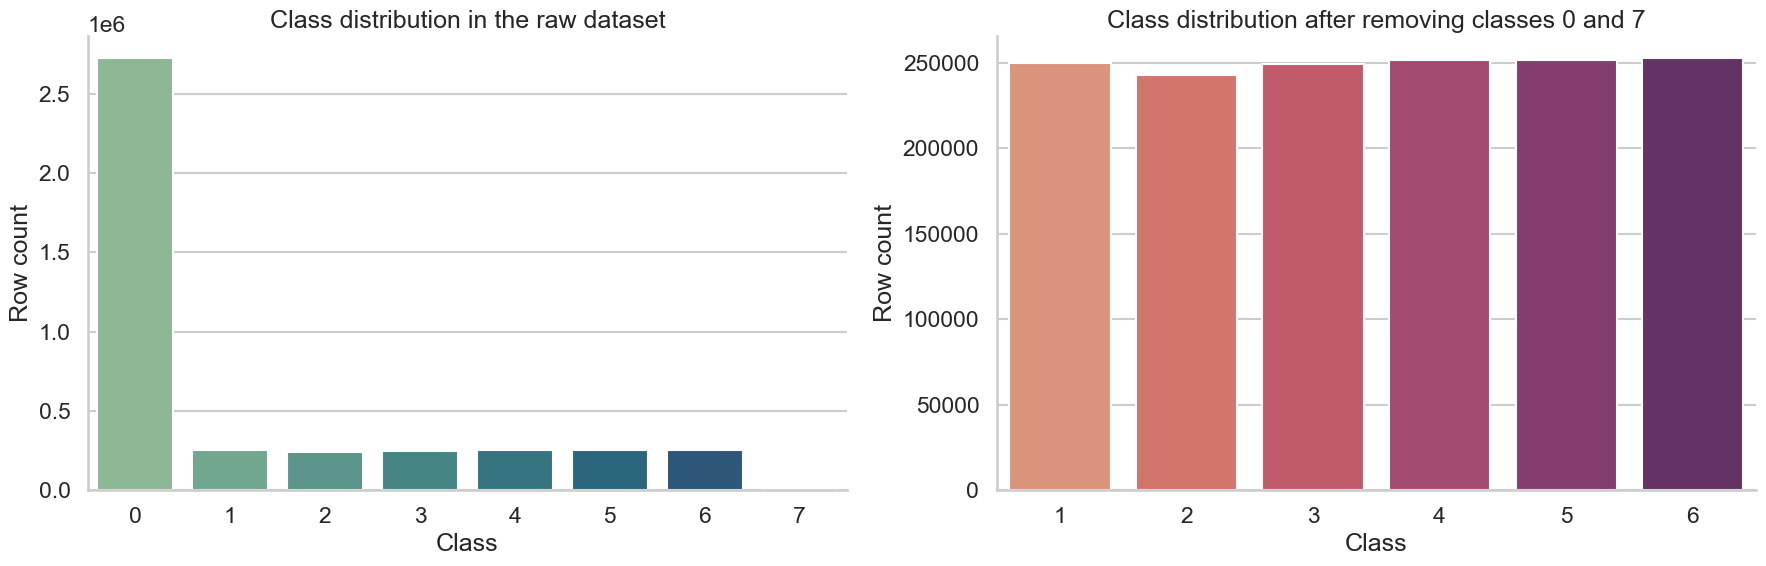

,mean,std,min,max
channel1,-0.000008,0.000163,-0.00128,0.00127
channel2,-0.000009,0.000119,-0.00128,0.00127
channel3,-0.000010,0.000124,-0.00128,0.00127
channel4,-0.000010,0.000226,-0.00128,0.00127
channel5,-0.000016,0.000272,-0.00128,0.00127
channel6,-0.000011,0.000215,-0.00128,0.00127
channel7,-0.000009,0.000153,-0.00128,0.00127
channel8,-0.000010,0.000172,-0.00128,0.00127


In [3]:
gesture_map = {
    0: 'transition',
    1: 'rest',
    2: 'fist',
    3: 'wrist flexion',
    4: 'wrist extension',
    5: 'radial deviation',
    6: 'ulnar deviation',
    7: 'extended palm',
}

eda_summary = pd.DataFrame(
    [
        ('Rows', len(raw_df)),
        ('Columns', raw_df.shape[1]),
        ('Unique subjects', raw_df['subject_id'].nunique()),
        ('Inferred sessions', raw_df[['subject_id', 'session_id']].drop_duplicates().shape[0]),
        ('Missing values', int(raw_df.isna().sum().sum())),
        ('Duplicate rows', int(raw_df.duplicated().sum())),
        ('Class 7 subjects', sorted(raw_df.loc[raw_df['class'] == 7, 'subject_id'].unique().tolist())),
    ],
    columns=['Metric', 'Value'],
)
display(eda_summary)

class_counts_full = raw_df['class'].value_counts().sort_index().rename_axis('class').reset_index(name='count')
class_counts_full['gesture'] = class_counts_full['class'].map(gesture_map)
filtered_raw = raw_df.loc[~raw_df['class'].isin([0, 7])].copy()
class_counts_filtered = filtered_raw['class'].value_counts().sort_index().rename_axis('class').reset_index(name='count')
class_counts_filtered['gesture'] = class_counts_filtered['class'].map(gesture_map)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=class_counts_full, x='class', y='count', hue='gesture', dodge=False, ax=axes[0], palette='crest')
axes[0].set_title('Class distribution in the raw dataset')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Row count')
axes[0].legend_.remove()

sns.barplot(data=class_counts_filtered, x='class', y='count', hue='gesture', dodge=False, ax=axes[1], palette='flare')
axes[1].set_title('Class distribution after removing classes 0 and 7')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Row count')
axes[1].legend_.remove()
plt.tight_layout()
plt.show()

signal_summary = raw_df[[f'channel{i}' for i in range(1, 9)]].describe().T[['mean', 'std', 'min', 'max']]
display(signal_summary)

The raw dataset is dominated by transition samples (`class 0`), which is exactly why the benchmark excludes them during training. After that filtering step, the six retained gesture classes are reasonably balanced.

The channel summary also shows that the raw EMG values are centered very close to zero and live on a small amplitude scale, which makes DC offset removal and consistent normalization sensible preprocessing steps.

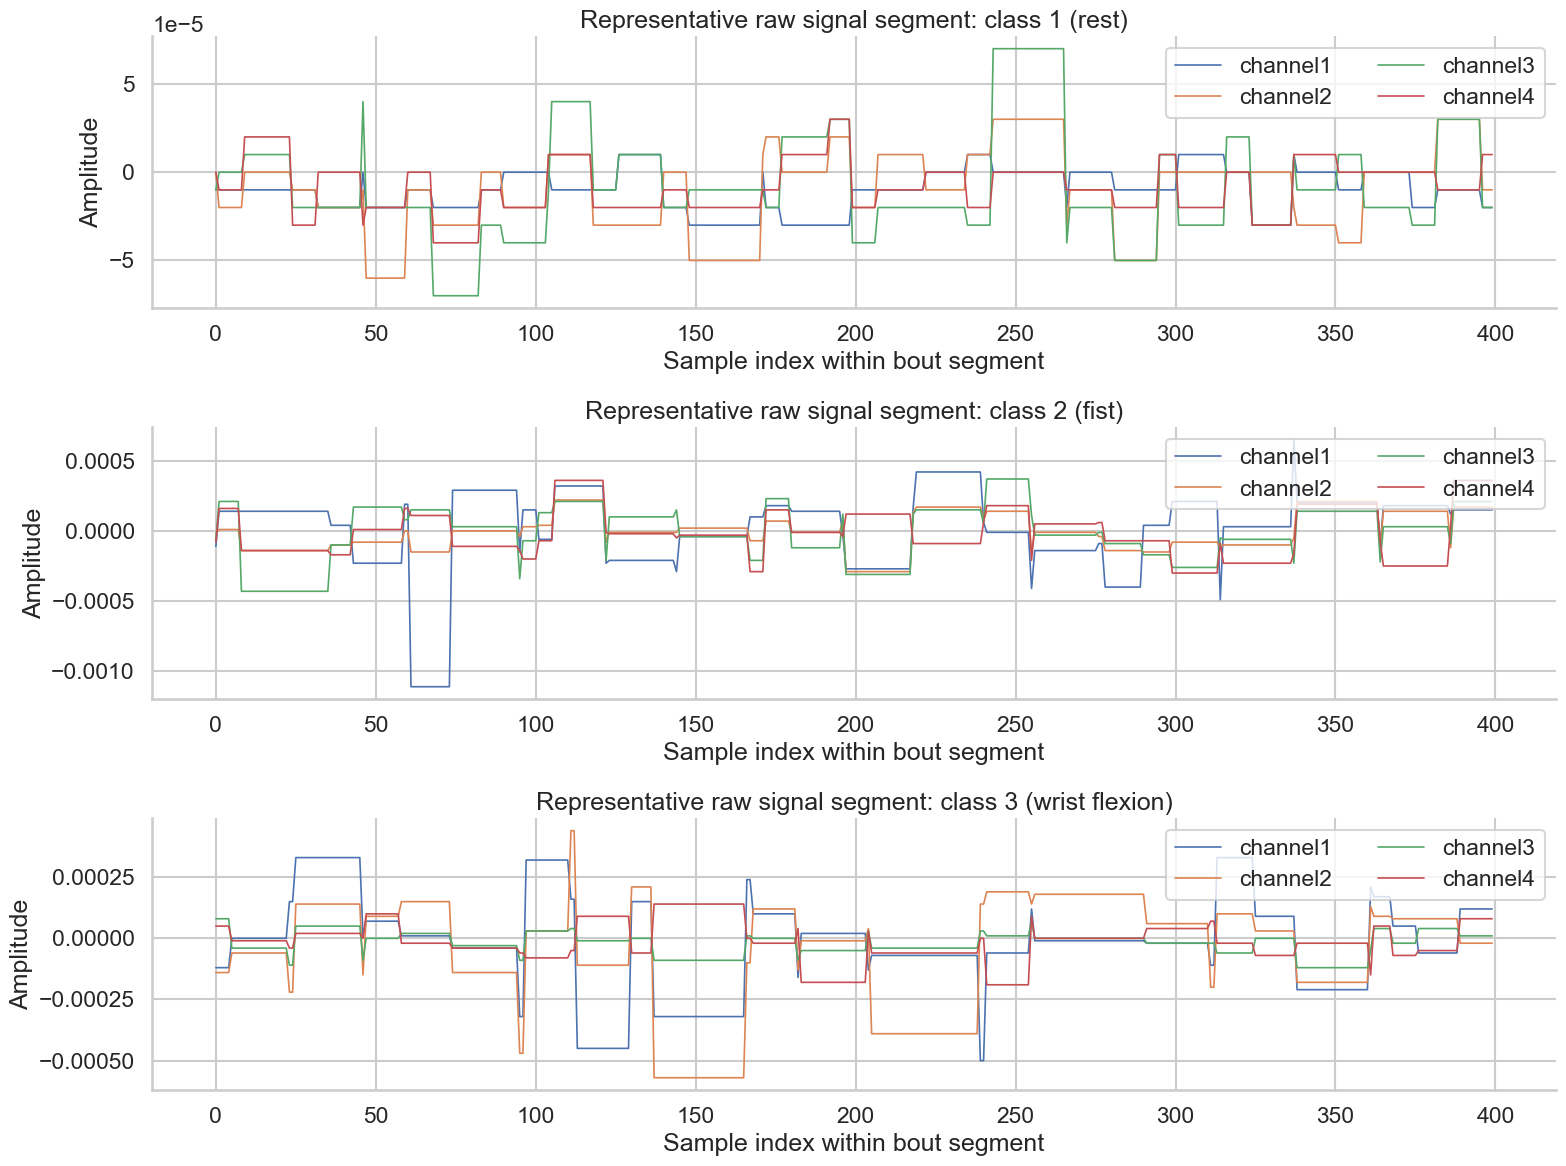

In [4]:
filtered_for_plot = filtered_raw.copy()
filtered_for_plot = build_bouts(filtered_for_plot)

selected_examples = []
for gesture in [1, 2, 3]:
    candidate_bout = filtered_for_plot.loc[filtered_for_plot['class'] == gesture, 'bout_index'].iloc[0]
    bout_frame = filtered_for_plot.loc[filtered_for_plot['bout_index'] == candidate_bout].head(400).copy()
    bout_frame['relative_sample'] = np.arange(len(bout_frame))
    selected_examples.append((gesture, bout_frame))

fig, axes = plt.subplots(len(selected_examples), 1, figsize=(16, 12), sharex=False)
channels_to_plot = ['channel1', 'channel2', 'channel3', 'channel4']
for axis, (gesture, bout_frame) in zip(axes, selected_examples):
    melted = bout_frame.melt(id_vars=['relative_sample'], value_vars=channels_to_plot, var_name='channel', value_name='amplitude')
    sns.lineplot(data=melted, x='relative_sample', y='amplitude', hue='channel', ax=axis, linewidth=1.2)
    axis.set_title(f"Representative raw signal segment: class {gesture} ({gesture_map[gesture]})")
    axis.set_xlabel('Sample index within bout segment')
    axis.set_ylabel('Amplitude')
    axis.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

These representative traces illustrate the multichannel structure of the problem: each gesture is observed as a short synchronized eight-channel signal rather than as a single scalar feature row. The modeling pipeline therefore transforms short windows of signal into a structured feature table before classification.

## 4. Signal preprocessing

The winning pipeline is a handcrafted-feature workflow. It does not feed raw time series directly into a neural network. Instead, it performs leakage-aware segmentation and feature extraction using the configuration found in `artifacts/best_grouped_result.json` and the exact functions defined in `train.py`.

Winning preprocessing choices:

- filter out classes `0` and `7`
- reconstruct gesture bouts so windows do not cross label or session boundaries
- segment the signal into `225 ms` windows
- use `40%` overlap, which yields a step size of `135 ms`
- remove DC offset within each window
- normalize using per-session statistics
- extract per-channel time-domain, EMG-specific, distributional, Hjorth, autoregressive, and frequency features
- aggregate the same feature names across channels with summary statistics
- do not use sample entropy, channel-pair correlation features, rectification, detrending, or PCA

,Item,Value
0,Sample rate (Hz),1000.0
1,Window length (samples),225.0
2,Step size (samples),135.0
3,Window count,10092.0
4,Feature count,396.0
5,Subject groups,36.0
6,Sessions after reconstruction,72.0


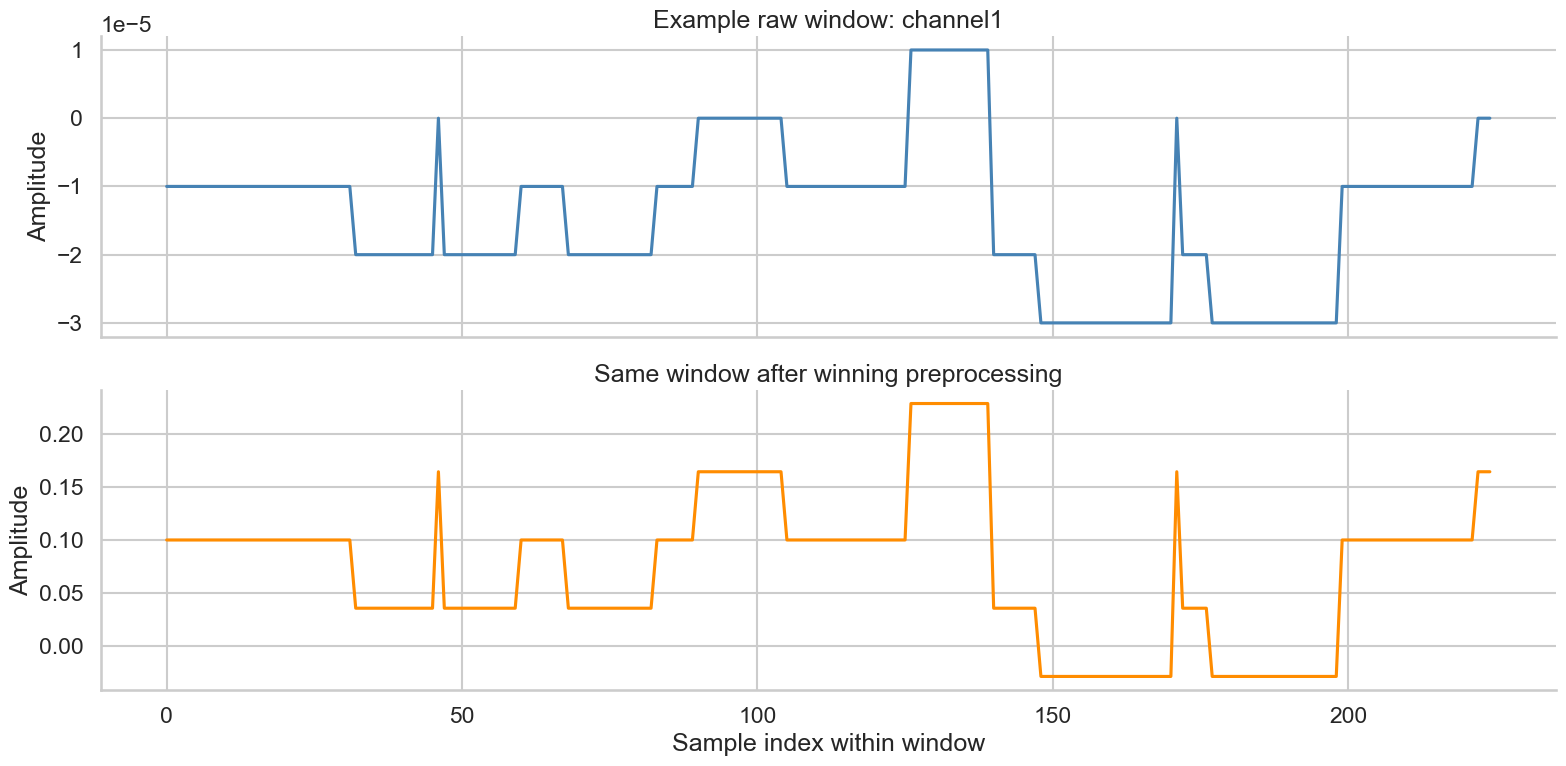

,0,1,2,3,4
channel1_mav,0.083719,0.101473,0.089104,0.086418,0.096400
channel1_rms,0.100849,0.114975,0.103457,0.098858,0.114048
channel1_var,0.004949,0.007998,0.005482,0.004552,0.007786
channel1_wl,1.607984,2.122539,1.865261,1.543665,2.251178
channel1_zc,4.000000,6.000000,10.000000,10.000000,7.000000
channel1_ssc,2.000000,3.000000,2.000000,2.000000,2.000000
channel1_wamp,16.000000,19.000000,18.000000,16.000000,20.000000
channel1_iemg,18.836732,22.831380,20.048294,19.444073,21.690068
channel1_aac,0.007178,0.009476,0.008327,0.006891,0.010050
channel1_dasdv,0.029462,0.036718,0.033010,0.027180,0.040996


,Component,Count
0,Per-channel features on each sensor,33
1,Channels,8
2,Across-channel summary features,132
3,Total engineered features,396


In [5]:
bundle = load_dataset()
modeling_frame = filter_frame(bundle.frame, config)
modeling_frame = build_bouts(modeling_frame)
windows = enumerate_windows(modeling_frame, bundle.sample_rate_hz, config, rng)
features, labels, groups = build_feature_table(modeling_frame, windows, bundle, config, rng)

window_size_samples = max(8, int(round(bundle.sample_rate_hz * config.window_ms / 1000.0)))
step_size_samples = max(1, int(round(window_size_samples * (1.0 - config.overlap_ratio))))

preprocessing_summary = pd.DataFrame(
    [
        ('Sample rate (Hz)', bundle.sample_rate_hz),
        ('Window length (samples)', window_size_samples),
        ('Step size (samples)', step_size_samples),
        ('Window count', len(windows)),
        ('Feature count', features.shape[1]),
        ('Subject groups', len(pd.unique(groups))),
        ('Sessions after reconstruction', modeling_frame[['subject_id', 'session_id']].drop_duplicates().shape[0]),
    ],
    columns=['Item', 'Value'],
)
display(preprocessing_summary)

normalization_stats = normalization_lookup(modeling_frame, bundle.channels, config)
example_record = windows[0]
example_raw_window = modeling_frame.loc[example_record.start_idx:example_record.end_idx - 1, bundle.channels].to_numpy(dtype=np.float32)
example_processed_window = apply_preprocessing(
    example_raw_window,
    config,
    normalization_stats[(example_record.subject, example_record.session)],
)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(example_raw_window[:, 0], color='steelblue')
axes[0].set_title('Example raw window: channel1')
axes[0].set_ylabel('Amplitude')
axes[1].plot(example_processed_window[:, 0], color='darkorange')
axes[1].set_title('Same window after winning preprocessing')
axes[1].set_xlabel('Sample index within window')
axes[1].set_ylabel('Amplitude')
plt.tight_layout()
plt.show()

feature_preview = features.head().T.head(20)
display(feature_preview)

per_channel_feature_count = len([col for col in features.columns if col.startswith('channel1_')])
summary_feature_count = len([col for col in features.columns if col.startswith('summary_')])
feature_family_breakdown = pd.DataFrame(
    [
        ('Per-channel features on each sensor', per_channel_feature_count),
        ('Channels', len(bundle.channels)),
        ('Across-channel summary features', summary_feature_count),
        ('Total engineered features', features.shape[1]),
    ],
    columns=['Component', 'Count'],
)
display(feature_family_breakdown)

The resulting design matrix exactly matches the winning autoresearch run: `10092` windows and `396` engineered features. That agreement is an important verification step because it confirms the notebook is reconstructing the same preprocessing and feature-generation logic as the search pipeline.

## 5. Partitioning Dataset and Creating Data loaders

Because the winning approach is feature-based and uses scikit-learn, literal PyTorch-style `DataLoader` objects are not needed. The appropriate equivalent is the prepared feature matrix together with the label vector and the subject-group assignments used for leakage-aware splitting.

This section performs two related tasks:

1. reproduce the search-time grouped evaluation used by autoresearch
2. create a separate final subject-held-out train/test split for the polished final model report

In [6]:
reproduced_cv = evaluate_features(features, labels, groups, config, 0.0)
reproduced_cv_metrics = pd.DataFrame([reproduced_cv.metrics])
reproduced_cv_folds = pd.DataFrame(reproduced_cv.fold_summaries)

print('Reproduced grouped CV metrics:')
display(reproduced_cv_metrics)
print('Fold-level grouped CV summary:')
display(reproduced_cv_folds)

group_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_SEED)
train_idx, test_idx = next(group_splitter.split(features, labels, groups=groups))

X_train = features.iloc[train_idx].copy()
X_test = features.iloc[test_idx].copy()
y_train = labels[train_idx]
y_test = labels[test_idx]
groups_train = groups[train_idx]
groups_test = groups[test_idx]

split_summary = pd.DataFrame(
    [
        ('Training windows', X_train.shape[0]),
        ('Test windows', X_test.shape[0]),
        ('Training features', X_train.shape[1]),
        ('Held-out subject groups', len(pd.unique(groups_test))),
        ('Training subject groups', len(pd.unique(groups_train))),
    ],
    columns=['Split statistic', 'Value'],
)

display(split_summary)

display(pd.DataFrame({'train_class_count': pd.Series(y_train).value_counts().sort_index(), 'test_class_count': pd.Series(y_test).value_counts().sort_index()}))

Reproduced grouped CV metrics:


,f1_macro,accuracy,balanced_accuracy
0,0.877671,0.877086,0.877407


Fold-level grouped CV summary:


,fold,f1_macro,accuracy,balanced_accuracy
0,1.0,0.891145,0.890952,0.891049
1,2.0,0.864196,0.863221,0.863765


,Split statistic,Value
0,Training windows,7914
1,Test windows,2178
2,Training features,396
3,Held-out subject groups,8
4,Training subject groups,28


,train_class_count,test_class_count
1,1316,364
2,1273,359
3,1319,360
4,1329,363
5,1335,366
6,1342,366


The grouped CV step above is the closest apples-to-apples comparison with the autoresearch benchmark. The holdout split below serves a different purpose: it creates one clean final evaluation partition so that the notebook can fit a final model on the full training portion and then report performance on entirely unseen subjects.

## 6. Model

The winning classifier is an `ExtraTreesClassifier` wrapped inside the repository's sklearn pipeline. This is a compact tree-based model, which makes it a strong fit for a handcrafted-feature benchmark: it can capture nonlinear structure in the engineered EMG features without requiring a deep raw-signal architecture.

In [7]:
model_pipeline = build_pipeline(config)
model_summary = pd.DataFrame(
    [
        ('Pipeline steps', ' -> '.join(name for name, _ in model_pipeline.steps)),
        ('Model family', config.model_family),
        ('Hyperparameters', json.dumps(model_params, sort_keys=True)),
        ('Uses active StandardScaler stage', any(name == 'scaler' for name, _ in model_pipeline.steps)),
        ('Uses PCA stage', any(name == 'pca' for name, _ in model_pipeline.steps)),
    ],
    columns=['Model detail', 'Value'],
)
display(model_summary)
model_pipeline

,Model detail,Value
0,Pipeline steps,imputer -> model
1,Model family,extra_trees
2,Hyperparameters,"{""max_depth"": null, ""min_samples_leaf"": 1, ""n_..."
3,Uses active StandardScaler stage,False
4,Uses PCA stage,False


,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,350


## 7. Model training

For this final notebook, the model is trained once on the full designated training partition created above. Because the winner is a classical sklearn model, there is no epoch-based training loop. The fit itself is the complete training procedure.

In [8]:
train_start = time.perf_counter()
model_pipeline.fit(X_train, y_train)
train_runtime_seconds = time.perf_counter() - train_start

training_summary = pd.DataFrame(
    [
        ('Training windows used', X_train.shape[0]),
        ('Features used', X_train.shape[1]),
        ('Training runtime (seconds)', round(train_runtime_seconds, 3)),
    ],
    columns=['Training summary', 'Value'],
)
display(training_summary)

,Training summary,Value
0,Training windows used,7914.000
1,Features used,396.000
2,Training runtime (seconds),0.667


## 8. Model Evaluation

The final evaluation is performed on the untouched held-out subject split. The metrics reported here answer a different question from the grouped cross-validation result in `artifacts/best_grouped_result.json`.

- The grouped CV score summarizes the search-time benchmark across two subject folds.
- The final holdout score summarizes one clean train/test partition for presentation.

Both are useful, and any gap between them should be interpreted in that context rather than as evidence that the notebook changed the winning pipeline.

,accuracy,macro_f1,balanced_accuracy
0,0.928375,0.928314,0.928194


Classification report:


,precision,recall,f1-score,support
1,1.000000,1.000000,1.000000,364.000000
2,0.950292,0.905292,0.927247,359.000000
3,0.914706,0.863889,0.888571,360.000000
4,0.933702,0.931129,0.932414,363.000000
5,0.900262,0.937158,0.918340,366.000000
6,0.876607,0.931694,0.903311,366.000000
accuracy,0.928375,0.928375,0.928375,0.928375
macro avg,0.929262,0.928194,0.928314,2178.000000
weighted avg,0.929163,0.928375,0.928355,2178.000000


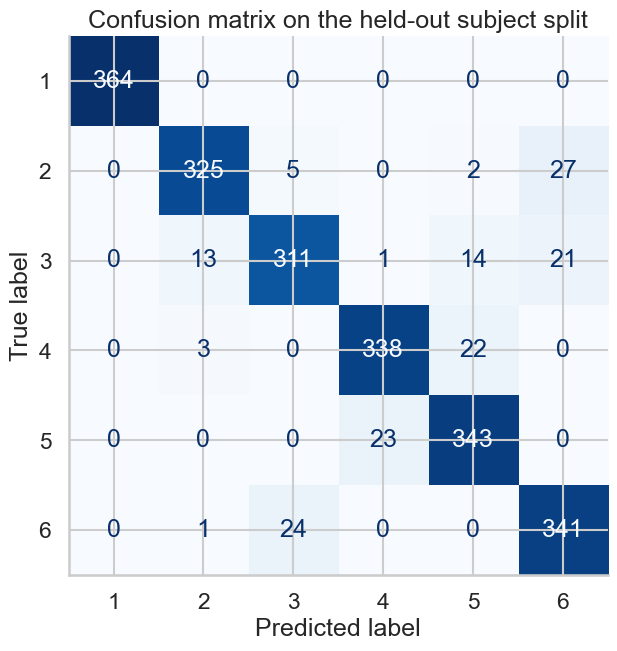

,Evaluation view,Accuracy,Macro F1,Balanced Accuracy
0,Autoresearch best grouped CV,0.880147,0.880840,0.880490
1,Notebook reproduced grouped CV,0.877086,0.877671,0.877407
2,Notebook final subject holdout,0.928375,0.928314,0.928194


In [9]:
y_pred = model_pipeline.predict(X_test)

holdout_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'macro_f1': f1_score(y_test, y_pred, average='macro'),
    'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
}
display(pd.DataFrame([holdout_metrics]))

report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
print('Classification report:')
display(report_df)

cm = confusion_matrix(y_test, y_pred, labels=sorted(pd.unique(y_test)))
fig, ax = plt.subplots(figsize=(8, 7))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(pd.unique(y_test)))
cmd.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion matrix on the held-out subject split')
plt.show()

comparison_table = pd.DataFrame(
    [
        {
            'Evaluation view': 'Autoresearch best grouped CV',
            'Accuracy': winner['metrics']['accuracy'],
            'Macro F1': winner['metrics']['f1_macro'],
            'Balanced Accuracy': winner['metrics']['balanced_accuracy'],
        },
        {
            'Evaluation view': 'Notebook reproduced grouped CV',
            'Accuracy': reproduced_cv.metrics['accuracy'],
            'Macro F1': reproduced_cv.metrics['f1_macro'],
            'Balanced Accuracy': reproduced_cv.metrics['balanced_accuracy'],
        },
        {
            'Evaluation view': 'Notebook final subject holdout',
            'Accuracy': holdout_metrics['accuracy'],
            'Macro F1': holdout_metrics['macro_f1'],
            'Balanced Accuracy': holdout_metrics['balanced_accuracy'],
        },
    ]
)
display(comparison_table)

The comparison table should be read carefully. In this environment, the notebook reproduces the **current repository code path** for the winning configuration, and that grouped CV score is slightly lower than the historical value stored in `artifacts/best_grouped_result.json`. Because a direct `run_experiment(...)` call from `train.py` yields the same lower number, the most likely explanation is that `artifacts/best_grouped_result.json` was produced from an earlier experiment context or code snapshot even though the high-level configuration still matches.

The final holdout score is higher than either grouped CV result because it is based on one particular subject-held-out split rather than the average over two grouped folds. That does **not** mean the model should be judged only by the higher value; the grouped CV result remains the more conservative benchmark-style estimate.

### Conclusion

The winning pipeline is a feature-based EMG classifier built around:

- leakage-aware subject grouping
- `225 ms` windows with `40%` overlap
- per-session normalization plus DC offset removal
- a broad handcrafted feature set spanning time, EMG-specific, distributional, Hjorth, autoregressive, and frequency descriptors
- an `ExtraTreesClassifier` with `350` trees

This combination likely worked well because the dataset is structured, moderately sized, and strongly driven by signal-processing characteristics. In that setting, careful segmentation and informative EMG features can outperform more complex raw-signal modeling approaches.

A natural next step after final evaluation would be to retrain the same validated pipeline on all available eligible data for deployment, but that should happen only after preserving a clean benchmark result such as the holdout evaluation reported above.

Export model and summary

In [10]:
from pathlib import Path
import joblib
import json
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report

# ---- Paths ----
export_path = Path.cwd() / "artifacts" / "final_model.joblib"
metrics_path = Path.cwd() / "artifacts" / "final_metrics.json"

# ---- Save model ----
joblib.dump(model_pipeline, export_path)

print(f"Model saved to: {export_path.resolve()}")

# ---- Evaluate model ----
# Assumes you have X_test, y_test already defined
y_pred = model_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
balanced_acc = balanced_accuracy_score(y_test, y_pred)

metrics = {
    "accuracy": float(accuracy),
    "f1_macro": float(f1_macro),
    "balanced_accuracy": float(balanced_acc)
}

# ---- Save metrics ----
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

# ---- Print summary ----
print("\n===== MODEL PERFORMANCE =====")
print(f"Accuracy:           {accuracy:.4f}")
print(f"F1 (macro):         {f1_macro:.4f}")
print(f"Balanced Accuracy:  {balanced_acc:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

print(f"\nMetrics saved to: {metrics_path.resolve()}")

Model saved to: /Users/lukehenderson/Documents/Projects/emg/artifacts/final_model.joblib

===== MODEL PERFORMANCE =====
Accuracy:           0.9284
F1 (macro):         0.9283
Balanced Accuracy:  0.9282

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       364
           2       0.95      0.91      0.93       359
           3       0.91      0.86      0.89       360
           4       0.93      0.93      0.93       363
           5       0.90      0.94      0.92       366
           6       0.88      0.93      0.90       366

    accuracy                           0.93      2178
   macro avg       0.93      0.93      0.93      2178
weighted avg       0.93      0.93      0.93      2178


Metrics saved to: /Users/lukehenderson/Documents/Projects/emg/artifacts/final_metrics.json
